In [1]:
import numpy as np
from math import *
import matplotlib.pyplot as plt
from time import time

# 1. Beam-Warming method (4 points)
The Beam-Warming method for the linear advection equation $u_t + au_x =0$ is given by
$$ U^{n+1}_j = U^n_j - \frac{ak}{2h} (3 U^n_j - 4U^n_{j-1} + U^n_{j-2} ) +
  \frac{a^2 k^2}{2h^2} (U^n_j - 2U^n_{j-1} + U^n_{j-2}) $$
where $U^n_j$ is the approximation of $u(jh,nk)$.

1. Use Taylor series to show that this method is second-order accurate.
2. For a given plane wave solution $U^0_j = e^{ij h \xi}$, compute the amplification factor $g(\xi)$, and hence determine the stability restriction for this method.

### Part 1

We use the expansions
\begin{align*}
    U^{n+1}_j &= u(jh, nk + k) = U_j^n + k u_t(jh, nk) + \frac{k^2}{2} u_{tt}(jh, nk) + \frac{k^3}{6} u_{ttt}(jh, nk) + O(k^4) \\
    U^n_{j-1} &= u(jh - h, nk) = U_j^n - h u_x(jh, nk) + \frac{h^2}{2} u_{xx}(jh, nk) - \frac{h^3}{6} u_{xxx}(jh, nk) + O(h^4) \\
    U^n_{j-2} &= u(jh -2h, nk) = U_j^n - 2hu_x(jh, nk) + 2h^2 u_{xx}(jh, nk) - \frac{4h^3}{3} u_{xxx}(jh, nk) + O(h^4)
\end{align*}

which allows us to expand the terms
\begin{align*}
    3U_j^n - 4U_{j-1}^n + U_{j-2}^n &= 2hu_x - \frac{2h^3}{3} u_{xxx} + O(h^4) \\
    U_j^n - 2U_{j-1}^n + U_{j-2}^n &= h^2 u_{xx} - h^3 u_{xxx} + O(h^4)
\end{align*}

If we assume that $u$ is smooth, then we also have
$$ u_t = -au_x \qquad u_{tt} = -a u_{xt} = -a u_{tx} = -a (-a u_{xx}) = a^2 u_{xx} $$

We write the iterative step as
$$ LHS = U_j^{n+1} - U_j^n = - \frac{ak}{2h} (3 U^n_j - 4U^n_{j-1} + U^n_{j-2} ) + \frac{a^2 k^2}{2h^2} (U^n_j - 2U^n_{j-1} + U^n_{j-2}) = RHS $$
and expand both sides using the above
\begin{align*}
    LHS &= ku_t + \frac{k^2}{2} u_{tt} + \frac{k^3}{6} u_{ttt} + \cdots \\
    &= -ak u_x + \frac{a^2k^2}{2} u_{xx} + O(k^3) \\
    RHS &= \left( -ak u_x + \frac{a kh^2}{3} u_{xxx} + \cdots \right) + \left( \frac{a^2k^2}{2} u_{xx} - \frac{a^2k^2h}{2} u_{xxx} + \cdots \right) \\
    &= -ak u_x + \frac{a^2k^2}{2} u_{xx} + O(h^3 + k^3)
\end{align*}

Thus both sides agree up to second order in $h$ and $k$, so this method is second-order accurate.

### Part 2
For the given solution, we get
$$ U^1_{j} = g(\xi) e^{ijh\zeta} = e^{ijh\zeta} - \frac{ak}{2h}(3 - 4e^{-ih\xi} + e^{-2ih\xi}) e^{ijh\xi} + \frac{a^2k^2}{2h^2} (1 - 2e^{-ih\xi} + e^{-2ih\xi}) e^{ijh\xi} $$
so the amplification factor is
\begin{align*}
    g(\xi) &= 1 - \frac{ak}{2h}(3 - 4e^{-ih\xi} + e^{-2ih\xi}) + \frac{a^2k^2}{2h^2} (1 - 2e^{-ih\xi} + e^{-2ih\xi}) \\
    &= 1 - \frac{ak}{h} \left( 1 - e^{-ih\xi} \right) - e^{-ih\xi}\left( \cos(\xi h) - 1 \right) \left( \frac{ak}{h} - \frac{a^2k^2}{h^2} \right) 
\end{align*}

Note that 
$$ \| A + B e^{-i\theta} \|^2 = A^2 + B^2 + 2AB \cos(\theta) $$

# 2. Beam-Warming cont. (9 points)
Dropping the last term in the Beam-Warming method gives
$$ U^{n+1}_j = U^n_j - \frac{ak}{2h} (3 U^n_j - 4U^n_{j-1} + U^n_{j-2} ) $$
which corresponds to forward Euler method in time, and a second-order one-sided derivative in space. Define $\nu = ak/h$.

1. Calculate the amplification factor $g(\xi)$ for a plane wave solution $U^0_j = e^{ijh\xi}$.
2. Define $A(\xi)= |g(\xi)|^2$ and calculate a Taylor series for $A$ at $\xi=0$ up to second order. Using the Taylor series, explain why we consider this numerical scheme to be unstable regardless of the choice of timestep.
3. Make two plots of $A(\xi)$ for $\nu = \frac{1}{100}$ using two different axis ranges:
    * $0\le h\xi \le 2\pi$ and $0.91 \le A \le 1.01$
    * $0\le h\xi \le 0.17$ and $1-10^{-6} \le A \le 1+10^{-6}$
4. Write a program to simulate this scheme on a periodic interval $[0,2\pi)$ using $N=40$ grid points and a grid spacing of $h = 2\pi/N$. Use the initial condition $u= \exp (2\sin x)$ and $\nu =\frac1{100}$. Plot the solution for $n=0,1000,2000,4000$. Define the root mean squared value of the solution,
$$ R(n) = \sqrt{\frac{1}{N} \sum_{j=0}^{N-1} (U^n_j)^2} $$
    Make a plot of $R$ over the range from $n=0$ to $n=10000$. You should find that $R$ does not grow over time, indicating that the method is stable.
5. Using the discrete Fourier transform, it can be shown that an arbitrary initial condition on the periodic interval can be written as
$$ U^0_j = \sum_{l=0}^{N-1} \alpha_l e^{ijlh} $$
    for some constants $\alpha_l$. Write down an expression for the general solution $U^n_j$. Using your answer, explain why your result in part (d) does not contradict the result in part (b).

### Part 1

From the previous part
$$ g(\xi) = 1 - \frac{ak}{2h} \left( 3 - 4e^{-ih\xi} + e^{-2ih\xi} \right) $$

### Part 2

### Part 3

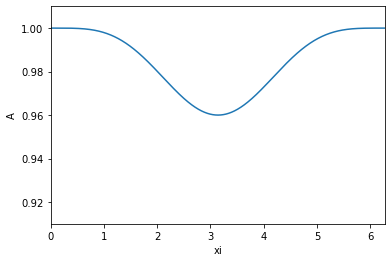

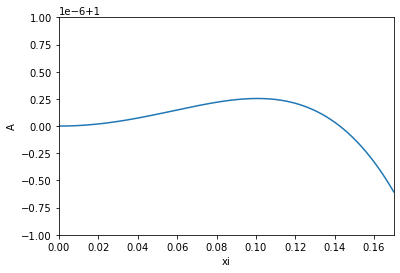

In [7]:
nu = 1/100

def A(x):
    return np.abs(1 - (nu/2) * (3 - 4*np.exp(-1j * x) + np.exp(-2 * 1j * x)))

hxis = np.linspace(0, 2 * np.pi, 1000)
As = [A(hxi) for hxi in hxis]

plt.plot(hxis, As)
plt.xlabel('xi')
plt.ylabel('A')
plt.xlim(0, 2 * np.pi)
plt.ylim(0.91, 1.01)
plt.show()

hxis = np.linspace(0, 0.17, 1000)
As = [A(hxi) for hxi in hxis]

plt.plot(hxis, As)
plt.xlabel('xi')
plt.ylabel('A')
plt.xlim(0, 0.17)
plt.ylim(1 - 1e-6, 1 + 1e-6)
plt.show()

### Part 4

In [4]:
print(np.abs(3j+4))

5.0


### Part 5

# 3. Lax-Wendroff method (7 points)
Consider the hyperbolic conservation equation
$$ q_t + [A(x) q]_x =0 $$
for a function on $q(x,t)$ on the periodic interval $[0,2\pi)$. Let 
$$A(x)=2+\frac{4}{3}\sin x$$

Following the finite volume approach, divide the intervals into $m$ domains $\mathcal{C}_i$ of length $h=\frac{2\pi}{m}$, for $i=\{0,1,\ldots,m-1\}$. Let $Q_i^n \approx q((i+\frac{1}{2})h, n\Delta t)$ be the discretized solution at the center of each $\mathcal{C}_i$. The generalized Lax-Wendroff scheme for this equation is given by
$$ Q^{n+1}_i = Q_i - \frac{\Delta t}{h} \left[ \mathcal{F}_{i+1/2}^n - \mathcal{F}_{i-1/2}^n \right] $$
where the fluxes are
$$ \mathcal{F}_{i-1/2}^n = \frac{A_{i-1} Q_{i-1}^n + A_i Q_i^n}{2} - \frac{A_{i-1/2}\Delta t}{2h} \left[A_iQ^n_i - A_{i-1}Q_{i-1}^n\right] $$

Here, $A_i = A( (i+\frac{1}{2})h)$ and $A_{i-1/2}=A(ih)$. It can be shown that the solution is time-periodic so that $q(x,t+T)=q(x,t)$ where $T=3\pi/\sqrt{5}$.

1. The CFL condition requires that $\Delta t \le \frac{h}{c}$ for stability. What is $c$ in this case?
2. Implement the method and set $\Delta t = \frac{h}{3c}$. Use the initial condition
$$ q(x,0) = \exp\left(\sin x + \frac{1}{2}\sin 4x\right) $$
    For $m=512$, plot snapshots of the solution for $t=0,\frac{T}{4},\frac{T}{2},\frac{3T}{4},T$. (Since multiples of $\Delta t$ do not exactly match these snapshot times, you may need to make a small adjustment to the timestep)
3. By considering a range of $m$ (e.g. $\sim 256$ and upward) with the initial condition in part (b), calculate the $L_2$ norm between the numerical solution at $t=T$ and the exact answer. Determine the order of convergence. When determining the order of convergence, you are interested in the asymptotic properites of error as $m$ gets large. You can ignore initial transients in error.
4. Repeat parts (b) and (c) for the initial condition
$$ q(x,0) = \max\{ \frac{\pi}{2}-|x-\pi|,0\} $$

### Part 1

### Part 2

In [ ]:
m = 512
h = 2*np.pi/m
c = 1  # from previous part
T = 3*np.pi/np.sqrt(5)
dt = h/3*c

### Part 3

### Part 4